In [1]:
import pandas as pd
import numpy as np
from scipy.stats import chi2_contingency
import statsmodels.formula.api as smf

df = pd.read_csv('marketing_clean_final.csv')

# 1. 단순 상관계수 (이진변수 간 Pearson 상관계수 = phi coefficient와 동일)
corr = df[['AnyAccepted', 'Response']].corr().iloc[0, 1]
print(f'[1] Pearson 상관계수: {corr:.4f}')
print()

# 2. 분할표(contingency table) 확인
ct = pd.crosstab(df['AnyAccepted'], df['Response'], margins=True)
ct.index = ['AnyAccepted=0', 'AnyAccepted=1', '합계']
ct.columns = ['Response=0', 'Response=1', '합계']
print('[2] 분할표 (교차표)')
print(ct)
print()

# 캠페인 반응률 계산
rate_0 = ct_raw.loc[0, 1] / ct_raw.loc[0].sum() * 100
rate_1 = ct_raw.loc[1, 1] / ct_raw.loc[1].sum() * 100

print('[2-1] 그룹별 캠페인 반응률')
print(f'AnyAccepted=0 그룹 반응률: {rate_0:.2f}%  ({ct_raw.loc[0,1]}명 / {ct_raw.loc[0].sum()}명)')
print(f'AnyAccepted=1 그룹 반응률: {rate_1:.2f}%  ({ct_raw.loc[1,1]}명 / {ct_raw.loc[1].sum()}명)')
print(f'반응률 배율: {rate_1/rate_0:.2f}배')
print()

# 3. 카이제곱 검정
ct_raw = pd.crosstab(df['AnyAccepted'], df['Response'])
chi2, p_value, dof, expected = chi2_contingency(ct_raw)

print('[3] 카이제곱 독립성 검정')
print(f'chi2 통계량: {chi2:.4f}')
print(f'p-value: {p_value:.8f}')
print(f'자유도: {dof}')
print(f'-> {"유의함 (연관 있음)" if p_value < 0.05 else "유의하지 않음 (독립적)"}  (유의수준 0.05 기준)')
print()

# 4. 오즈비 계산
a = ct_raw.loc[1, 1]  # AnyAccepted=1, Response=1
b = ct_raw.loc[1, 0]  # AnyAccepted=1, Response=0
c = ct_raw.loc[0, 1]  # AnyAccepted=0, Response=1
d = ct_raw.loc[0, 0]  # AnyAccepted=0, Response=0

odds_ratio = (a * d) / (b * c)
print('[4] 오즈비 (Odds Ratio)')
print(f'AnyAccepted=1 그룹 오즈: {a/b:.4f}')
print(f'AnyAccepted=0 그룹 오즈: {c/d:.4f}')
print(f'오즈비: {odds_ratio:.4f}')
print(f'-> AnyAccepted=1인 고객은 0인 고객보다 Response=1일 오즈가 {odds_ratio:.2f}배 높음')
print()

# 5. 로지스틱 회귀 (계수, p-value, 신뢰구간까지 한 번에)
model = smf.logit('Response ~ AnyAccepted', data=df).fit()
print()
print('[5] 로지스틱 회귀 결과')
print(model.summary())

print()
or_from_model = np.exp(model.params['AnyAccepted'])
ci = np.exp(model.conf_int().loc['AnyAccepted'])
print(f'오즈비 (로지스틱 회귀 기준): {or_from_model:.4f}')
print(f'95% 신뢰구간: [{ci[0]:.4f}, {ci[1]:.4f}]')
print(f'p-value: {model.pvalues["AnyAccepted"]:.6f}')

# 6. 그룹별 Response 비율 요약
print()
summary = df.groupby('AnyAccepted')['Response'].agg(['mean', 'count'])
summary.columns = ['Response 비율', '표본수']
summary['Response 비율'] = (summary['Response 비율'] * 100).round(2)
print('[6] 그룹별 Response 비율 요약')
print(summary)

[1] Pearson 상관계수: 0.3691

[2] 분할표 (교차표)
               Response=0  Response=1    합계
AnyAccepted=0        1475         138  1613
AnyAccepted=1         248         175   423
합계                   1723         313  2036



NameError: name 'ct_raw' is not defined

과거 캠페인 수락 경험은 이번 캠페인 반응 여부와 강하고 통계적으로 유의한 관계가 있다. 한 번이라도 캠페인에 반응했던 고객은, 그렇지 않은 고객보다 이번에도 반응할 가능성이 훨씬 높다 (반응률 기준 4.8배, 오즈 기준 7.5배). 이 결과는 여러 통계적 방법(카이제곱, 오즈비, 로지스틱 회귀)에서 일관되게 확인되어 신뢰도가 높다.

In [22]:
import pandas as pd
import numpy as np
import statsmodels.formula.api as smf

df = pd.read_csv('marketing_clean_final.csv')

# 통제 모델 (Income, MntWines, Age, Children, Education, Marital_Status 통제)
model3 = smf.logit(
    'Response ~ AnyAccepted + Income + MntWines + Age + Children + C(Education) + C(Marital_Status)',
    data=df
).fit()

print(model3.summary())

import pandas as pd
from statsmodels.stats.outliers_influence import variance_inflation_factor

# model3에 사용했던 연속형/순서형 변수들로 VIF 계산
# (범주형 Education, Marital_Status는 더미변수로 변환해서 함께 확인)
X_vif = pd.get_dummies(
    df[['Income', 'MntWines', 'Age', 'Children', 'Education', 'Marital_Status']],
    columns=['Education', 'Marital_Status'],
    drop_first=True
).astype(float)

X_vif.insert(0, 'const', 1.0)  # VIF 계산엔 상수항 필요

vif_data = pd.DataFrame()
vif_data['변수'] = X_vif.columns
vif_data['VIF'] = [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])]

print(vif_data[vif_data['변수'] != 'const'].round(2))

# 오즈비 및 신뢰구간 정리
result3 = pd.DataFrame({
    'coef': model3.params,
    'p_value': model3.pvalues,
    'odds_ratio': np.exp(model3.params),
    'CI_lower': np.exp(model3.conf_int()[0]),
    'CI_upper': np.exp(model3.conf_int()[1])
})

result3 = result3.round(4)
print(result3)

# 단독 모델과 최종 통제 모델만 비교
model1 = smf.logit('Response ~ AnyAccepted', data=df).fit(disp=0)
print()
print('=== AnyAccepted 오즈비 및 모델 설명력 비교 ===')
print(f"[1] 단독 모델   - 오즈비: {np.exp(model1.params['AnyAccepted']):.4f}, p-value: {model1.pvalues['AnyAccepted']:.6f}, Pseudo R²: {model1.prsquared:.4f}")
print(f"[3] 통제 모델   - 오즈비: {np.exp(model3.params['AnyAccepted']):.4f}, p-value: {model3.pvalues['AnyAccepted']:.6f}, Pseudo R²: {model3.prsquared:.4f}")
print()

# 파라미터 개수 대비 표본 안전성 확인
n_params = len(model3.params)
n_events = df['Response'].sum()
print(f'파라미터 개수: {n_params}')
print(f'Response=1 건수: {n_events}')
print(f'사건당 파라미터 비율: {n_events/n_params:.1f} (10~20 이상이면 안전)')

Optimization terminated successfully.
         Current function value: 0.348871
         Iterations 7
                           Logit Regression Results                           
Dep. Variable:               Response   No. Observations:                 2036
Model:                          Logit   Df Residuals:                     2023
Method:                           MLE   Df Model:                           12
Date:                Fri, 21 Aug 2026   Pseudo R-squ.:                  0.1870
Time:                        15:39:43   Log-Likelihood:                -710.30
converged:                       True   LL-Null:                       -873.71
Covariance Type:            nonrobust   LLR p-value:                 1.081e-62
                                    coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------------
Intercept                        -2.3035      0.795     -2.897      0.

과거 캠페인 참여 이력(AnyAccepted)은 소득, 지출, 나이, 자녀 수, 학력, 결혼상태를 모두 통제해도 이번 캠페인 반응(Response)에 강하고 독립적인 영향을 미치며(오즈비 6.27, p<0.001), 이 외에 PhD 학력과 적은 자녀 수는 반응 가능성을 높이고 기혼·동거 상태는 반응 가능성을 낮추는 유의한 변수로 확인됐다.

사용할 특징: ['AnyAccepted', 'Education_encoded', 'Children', 'Marital_encoded', 'Recency']
AnyAccepted          0
Education_encoded    0
Children             0
Marital_encoded      0
Recency              0
dtype: int64
스케일링 후 shape: (2036, 5)


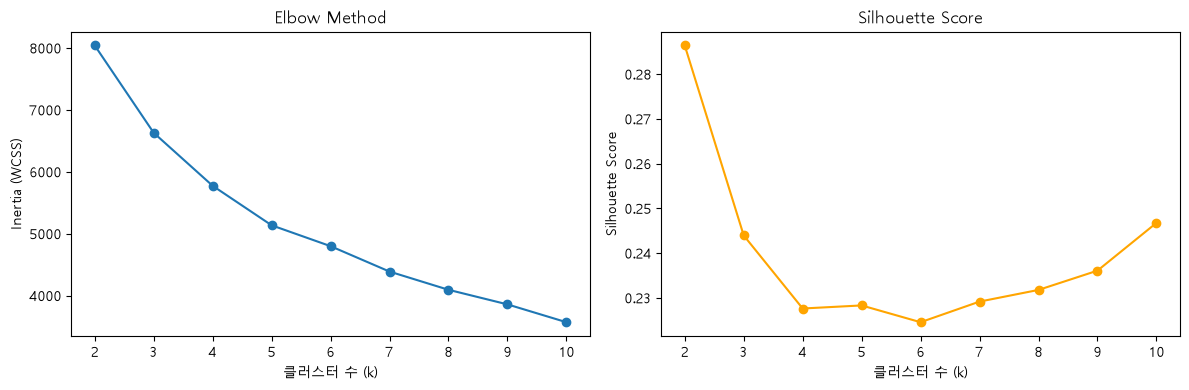

k=2: silhouette=0.2864
k=3: silhouette=0.2439
k=4: silhouette=0.2276
k=5: silhouette=0.2283
k=6: silhouette=0.2245
k=7: silhouette=0.2291
k=8: silhouette=0.2318
k=9: silhouette=0.2361
k=10: silhouette=0.2467


In [18]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
import matplotlib as mpl

mpl.rc('font', family='Malgun Gothic')
mpl.rcParams['axes.unicode_minus'] = False

df = pd.read_csv('marketing_clean_final.csv')

# 1. 범주형 변수 인코딩
education_order = {'Basic': 0, 'Graduation': 1, 'Master': 2, 'PhD': 3}
df['Education_encoded'] = df['Education'].map(education_order)

marital_order = {'Divorced': 0, 'Single': 1, 'Widow': 2, 'Together': 3, 'Married': 4}
df['Marital_encoded'] = df['Marital_Status'].map(marital_order)

# 2. 클러스터링에 사용할 특징 정의
feature_cols = ['AnyAccepted', 'Education_encoded', 'Children', 'Marital_encoded', 'Recency']
X = df[feature_cols].copy()

print('사용할 특징:', feature_cols)
print(X.isnull().sum())

# 3. 스케일링
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print('스케일링 후 shape:', X_scaled.shape)

# 4. 적정 k 탐색 (Elbow + Silhouette)
inertias = []
silhouette_scores = []
k_range = range(2, 11)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=777, n_init=10)
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    silhouette_scores.append(silhouette_score(X_scaled, labels))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(k_range, inertias, marker='o')
axes[0].set_xlabel('클러스터 수 (k)')
axes[0].set_ylabel('Inertia (WCSS)')
axes[0].set_title('Elbow Method')

axes[1].plot(k_range, silhouette_scores, marker='o', color='orange')
axes[1].set_xlabel('클러스터 수 (k)')
axes[1].set_ylabel('Silhouette Score')
axes[1].set_title('Silhouette Score')

plt.tight_layout()
plt.show()

for k, s in zip(k_range, silhouette_scores):
    print(f'k={k}: silhouette={s:.4f}')

PC1 설명분산: 24.6%
PC2 설명분산: 20.8%


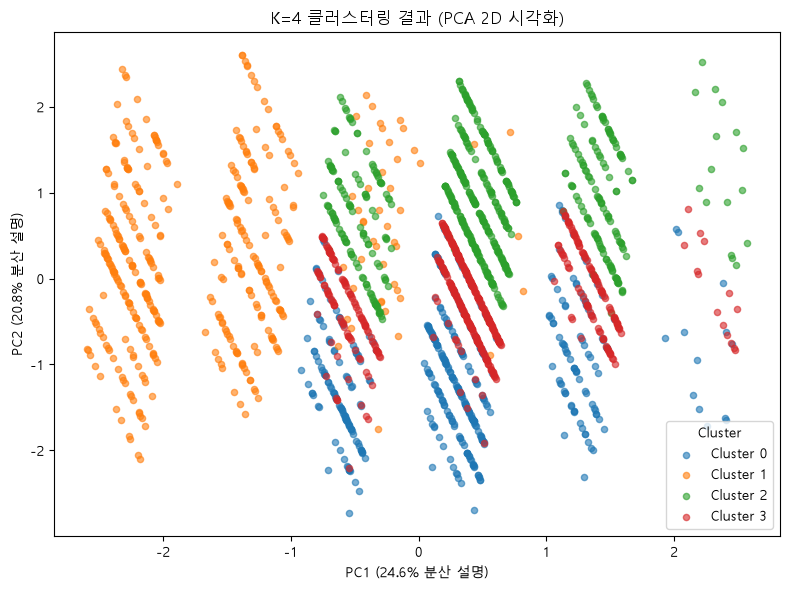

         count  AnyAccepted_rate  Education_avg  Children_avg  Marital_avg  \
Cluster                                                                      
0          478               0.0           1.37          0.99         0.69   
1          423               1.0           1.71          0.62         2.62   
2          595               0.0           2.51          1.06         3.21   
3          540               0.0           0.95          1.06         3.60   

         Recency_avg  Response_rate  Income_avg  
Cluster                                          
0              50.40           0.12    48453.45  
1              48.22           0.41    64984.70  
2              49.20           0.08    50582.79  
3              48.50           0.06    46675.61  
--- Cluster 0 (n=478) ---
Education 분포: {'Graduation': 0.62, 'Master': 0.27, 'PhD': 0.07, 'Basic': 0.04}
Marital_Status 분포: {'Single': 0.59, 'Divorced': 0.36, 'Widow': 0.05}

--- Cluster 1 (n=423) ---
Education 분포: {'Graduation': 0

In [21]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import matplotlib as mpl

mpl.rc('font', family='Malgun Gothic')
mpl.rcParams['axes.unicode_minus'] = False

df = pd.read_csv('marketing_clean_final.csv')

education_order = {'Basic': 0, 'Graduation': 1, 'Master': 2, 'PhD': 3}
df['Education_encoded'] = df['Education'].map(education_order)

marital_order = {'Divorced': 0, 'Single': 1, 'Widow': 2, 'Together': 3, 'Married': 4}
df['Marital_encoded'] = df['Marital_Status'].map(marital_order)

feature_cols = ['AnyAccepted', 'Education_encoded', 'Children', 'Marital_encoded', 'Recency']
X = df[feature_cols].copy()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

kmeans = KMeans(n_clusters=4, random_state=777, n_init=10)
df['Cluster'] = kmeans.fit_predict(X_scaled)

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)
df['PC1'] = X_pca[:, 0]
df['PC2'] = X_pca[:, 1]

print(f'PC1 설명분산: {pca.explained_variance_ratio_[0]*100:.1f}%')
print(f'PC2 설명분산: {pca.explained_variance_ratio_[1]*100:.1f}%')

# PCA 2D 산점도 시각화
fig, ax = plt.subplots(figsize=(8, 6))

colors = {0: 'tab:blue', 1: 'tab:orange', 2: 'tab:green', 3: 'tab:red'}

for c in sorted(df['Cluster'].unique()):
    sub = df[df['Cluster'] == c]
    ax.scatter(sub['PC1'], sub['PC2'], c=colors[c], label=f'Cluster {c}', alpha=0.6, s=20)

ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% 분산 설명)')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% 분산 설명)')
ax.set_title('K=4 클러스터링 결과 (PCA 2D 시각화)')
ax.legend(title='Cluster')

plt.tight_layout()
plt.show()
# 클러스터별 특성 프로파일 확인
cluster_profile = df.groupby('Cluster').agg(
    count=('ID', 'count'),
    AnyAccepted_rate=('AnyAccepted', 'mean'),
    Education_avg=('Education_encoded', 'mean'),
    Children_avg=('Children', 'mean'),
    Marital_avg=('Marital_encoded', 'mean'),
    Recency_avg=('Recency', 'mean'),
    Response_rate=('Response', 'mean'),
    Income_avg=('Income', 'mean')
).round(2)

print(cluster_profile)

# 클러스터별 Education, Marital_Status 세부 분포
for c in sorted(df['Cluster'].unique()):
    sub = df[df['Cluster'] == c]
    print(f'--- Cluster {c} (n={len(sub)}) ---')
    print('Education 분포:', sub['Education'].value_counts(normalize=True).round(2).to_dict())
    print('Marital_Status 분포:', sub['Marital_Status'].value_counts(normalize=True).round(2).to_dict())
    print()
